### League Analysis

We now have data for all eligible Premier League players in the 2025/26 season across four key metrics: Possession Ending Actions per 90 (PEA/90), both raw and possession adjusted; Shot Creating Actions per 90 (SCA/90), both raw and possession adjusted; Usage Rate; and Attacking Involvement. To begin the analysis, we will examine four positional groups: wingers, strikers, midfielders and fullbacks. For each group, PEA/90 will be compared against SCA/90 using both the raw and possession-adjusted metrics. Each data point will also be scaled according to the player's combined goals and assists (G+A), providing a third dimension that represents their direct goal involvement.

PEA provides a measure of a player's involvement in possession-ending actions, while SCA provides a measure of their creative output. Comparing these metrics across both raw and possession-adjusted data will allow us to investigate how a player's creative output relates to the amount of possession available to them and identify differences between positional groups.

From the resulting figures, we can identify players who combine high involvement with high creative output, while also considering their direct goal involvement and the possession context of their team.


In [1]:
# 1: Load and split the data
import pandas as pd
from pathlib import Path

# Data folders
project_folder = Path.cwd().parent 
player_data = pd.read_csv(project_folder / "data" / "player_usage_data.csv")

# Remove players with less than 900 minutes played (10 full games) across the season to eliminate any players who's per 90
# stats might be unreliable due to low minutes played
player_data = player_data[player_data["minutesPlayed"] >= 900]

# Create one final column for combined goals and assists
player_data["GA"] = player_data["goals"] + player_data["assists"]
player_data["GA"] = player_data["GA"].astype(float)
player_data["xGI"] = player_data["expectedGoals"] + player_data["expectedAssists"]

# Check the number of players in each group
print(player_data["positionGroup"].value_counts())

positionGroup
Midfielder    104
Fullback       66
Centerback     63
Winger         48
Striker        37
Name: count, dtype: int64


In [3]:
# 2: Create a dictionary for team kit colours for plotting
# Check teamId data type
print(player_data["teamId"].dtype)

kit_colours = {
    42 : "#EF0107",
    34 : "#FFFFFF",
    30 : "#005DAA",
    50 : "#E30613",
    41 : "#EB172B",
    60 : "#DA291C",
    40 : "#670e36",
    14 : "#DD0000",
    3 : "#FDB913",
    17 : "#6CADDF",
    43 : "#FFFFFF",
    37 : "#7C2C3B",
    33 : "#132257",
    7 : "#0055A5",
    35 : "#C1040B",
    38 : "#001489",
    6 : "#5F0041",
    48 : "#00009E",
    39 : "#231F20",
    44 : "#E51C25"}

int64


In [44]:
# 3: Create a function to plot the data for a given positional group of players
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_positions(df, position_name):
    
    # Extract positional data
    data = df[df["positionGroup"] == position_name]

    # Define default font
    plt.rcParams["font.family"] = "DIN Alternate"
    
    # Initialise the figure
    fig, ax = plt.subplots(1,1, figsize = (12,6), facecolor = "#404040")
    
    # Define the marker sizes
    sizes = 10 + data["GA"] * 40

    # Define the team colours
    point_colours = data["teamId"].map(kit_colours)
    
    # Plot PEA/90 v CC/90 on the first axis
    ax.scatter(data["PEA/90"],
                    data["SCA/90"],
                    s = sizes,
                    alpha = 0.8,
                    c = point_colours,
                    edgecolors = "#CCCCCC",
                    linewidth = 0.5)

    # Figure customisation
    ax.set_title(f"Premier League {position_name}s 2025/26",
                      fontsize = 16,
                      pad = 10,
                      color = "white",
                      loc = "left")
    ax.set_xlabel("PEA / 90 mins",
                      fontsize = 12,
                      color = "#CCCCCC")
    ax.set_ylabel("SCA / 90 mins",
                      fontsize = 12,
                      color = "#CCCCCC")
    ax.set_facecolor("#404040")
    ax.tick_params(axis = "both",
                  labelsize = 12,
                  labelcolor = "#CCCCCC",
                  color = "#CCCCCC")
    for spine in ax.spines.values():
        spine.set_color("#CCCCCC")
        spine.set_linewidth(1)


    # Define the top 10 players in PEA and CC per 90 to annotate on the figure
    top_players = set(pd.concat([data.nlargest(10, "PEA/90"),
                                 data.nlargest(10, "SCA/90")])["playerName"])
    for _, player in data[data["playerName"].isin(top_players)].iterrows():
        ax.annotate(
            player["playerName"],
            (player["PEA/90"], player["SCA/90"]),
            xytext=(0, -12),
            textcoords="offset points",
            ha = "center",
            color = "#CCCCCC",
            fontsize = 10)

    # Plot a linear regression 
    x = data["PEA/90"]
    y = data["SCA/90"]

    slope, intercept = np.polyfit(x,y,1)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    # Define y_pred for R^2 score
    y_pred = slope * x + intercept
    
    ax.plot(x_line, y_line, 
                 linestyle = "--", 
                 linewidth = 1, 
                 c = "#CCCCCC",
                 alpha = 1)
    plt.savefig(project_folder / "figures" / "positions" / f"{position_name}.jpg",
               format = "jpg",
               dpi = 150)

    plt.show()

    

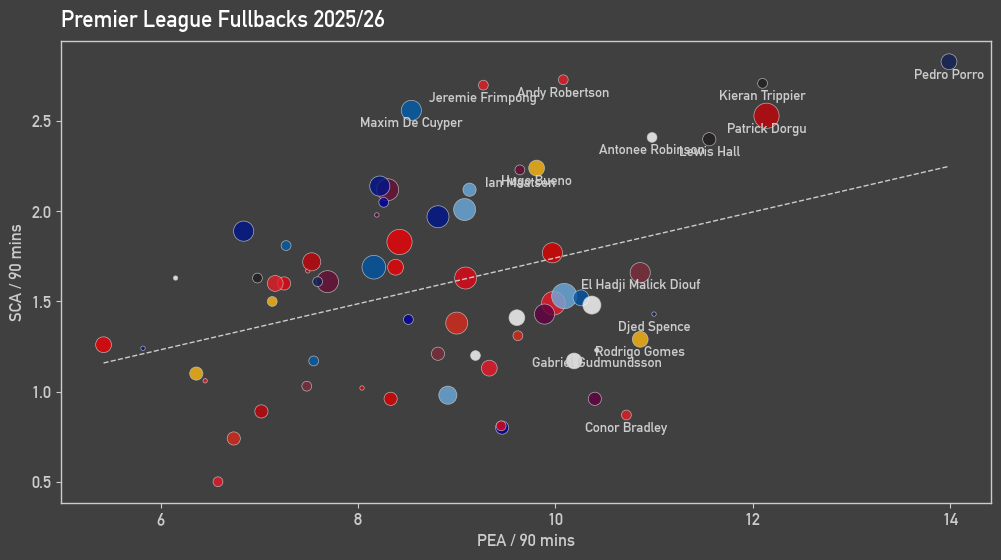

In [46]:
# 4: Fullbacks
plot_positions(player_data, "Fullback")

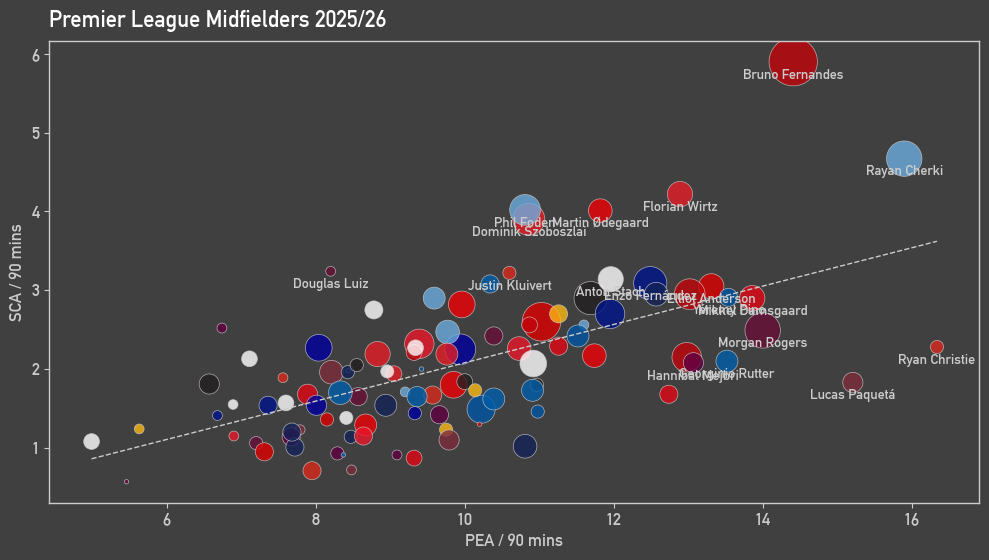

In [48]:
# 5: Midfielders
plot_positions(player_data, "Midfielder")

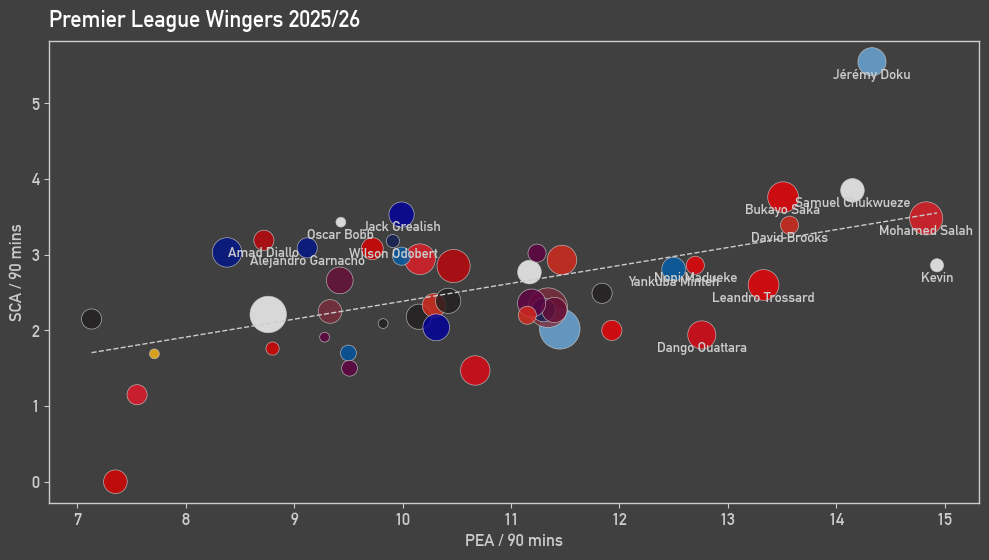

In [50]:
# 5: Wingers
plot_positions(player_data, "Winger")

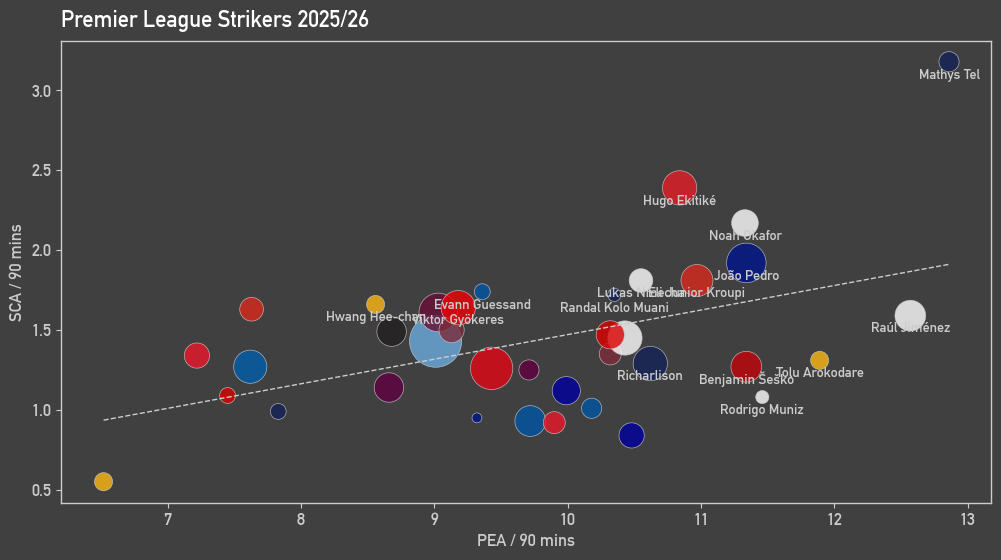

In [52]:
# 6: Strikers
plot_positions(player_data, "Striker")

## Notes
Possession adjusted values did not seem to be a worthwhile feature. Intuatively I expected SCA and PEA to incerease lineraly with the amount of possession a team had. As such I adjusetd these metrics for an average team possession value of 50% across the league. However, this did not produce better results. The R^2 values were as such: 
- Fullbacks: 0.154 -> 0.122 pos adjusted
- Midfielders: 0.371 -> 0.263 pos adjusted
- Wingers: 0.293 -> 0.170 pos adjusted
- Strikers: 0.229 -> 0.159 pos adjusted

So a clear decrease in the variance explained in the two variables when adjusted for possession. 